<a href="https://colab.research.google.com/github/egitonga395/kamilimu_assignments/blob/erick_python_libraries_2/erick_python_libraries_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Datascince python Libraries II assignment- data visualization.

In [14]:
import pandas as pd

athletes = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-07-27/athlete_events.csv")

countries = pd.read_csv("https://raw.githubusercontent.com/google/dspl/master/samples/google/canonical/countries.csv")

#SECTION 1

##QUESTION 1
Plot a bar graph of the top 5 countries with the highest number of athletes. Display the athlete count value on top of each bar.

In [15]:
#start by looking at the data
athletes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


,ID,Name,Sex,Age,Height,Weight,Team,Games,Year,Season,City,Sport,Event,Medal
NOC,,,,,,,,,,,,,,
USA,18853,18853,18853,18555,14828,14293,18853,18853,18853,18853,18853,18853,18853,5637
FRA,12758,12758,12758,11409,8271,8023,12758,12758,12758,12758,12758,12758,12758,1777
GBR,12256,12256,12256,11502,7942,7891,12256,12256,12256,12256,12256,12256,12256,2068
ITA,10715,10715,10715,10321,8045,7726,10715,10715,10715,10715,10715,10715,10715,1637
GER,9830,9830,9830,9657,7417,7342,9830,9830,9830,9830,9830,9830,9830,2165


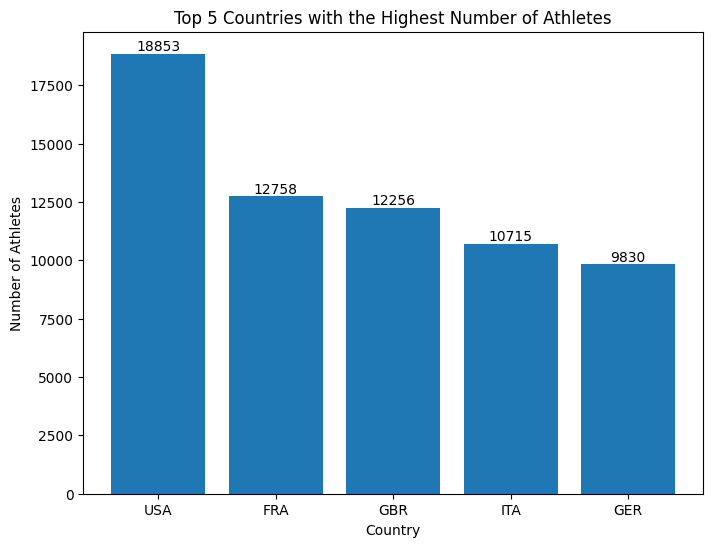

In [16]:
#start by grouping the atheletes by country,
# the count the number of athletes in each country,
# and then sort the countries by the number of atheletes, and take the top 5 countries
import matplotlib.pyplot as plt
countrys = athletes.groupby('NOC').count().sort_values(by='Name', ascending=False).head(5)
fig, ax = plt.subplots(figsize=(8,6))
bp = ax.bar(countrys.index, countrys['Name'])#countrys["Name"].plot(kind='bar', ax=ax)
ax.bar_label(bp, label_type='edge')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Athletes')
ax.set_title('Top 5 Countries with the Highest Number of Athletes')
countrys.head()


##QUESTION 2
Create a bar chart showing athlete counts by season (Summer and Winter). Set y-axis ticks from 0 to max count in steps of 5000. Assign summer the color turquoise and winter the color cyan. Set alpha=0.5 for transparency.

Text(0.5, 1.0, 'Athlete Counts by Season (Summer and Winter)')

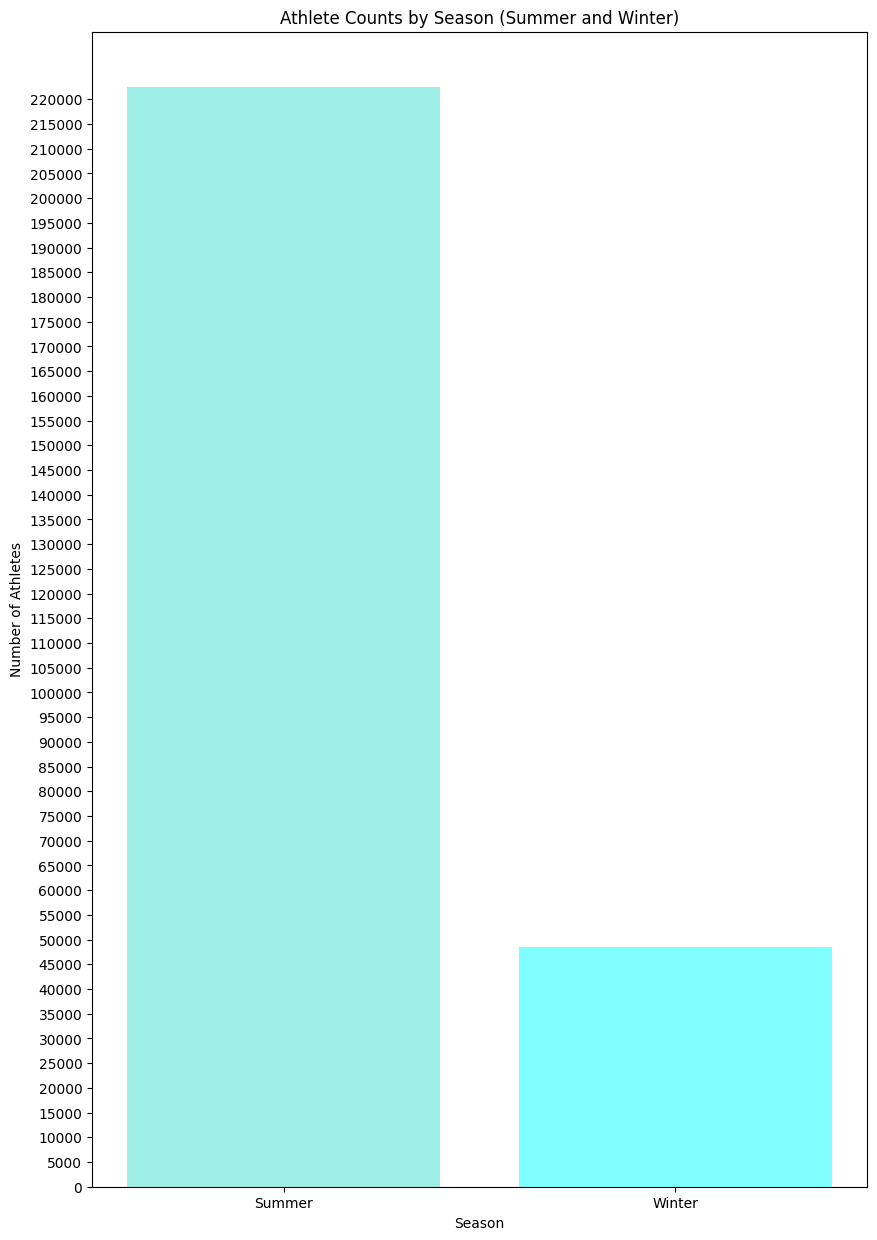

In [17]:
#its a comparison betweem the two season
values = athletes.groupby('Season').count().sort_values(by='Name', ascending=False)
fig, ax = plt.subplots(figsize=(10,15))
ax.bar(values.index, values['Name'], color=['turquoise', 'cyan'], alpha=0.5)
ax.set_yticks(range(0, values['Name'].max(), 5000))
ax.set_xlabel('Season')
ax.set_ylabel('Number of Athletes')
ax.set_title('Athlete Counts by Season (Summer and Winter)')

##QUESTION 3
Create a stacked bar chart where each bar represents a type of medal (Gold, Silver, Bronze), and the height of each bar shows the total number of times that medal was won. Each bar should be divided (stacked) by gender to show how many of those medals were won by male and female athletes. Move the legend to the right, outside the plot.

Text(0, 0.5, 'Number of Athletes')

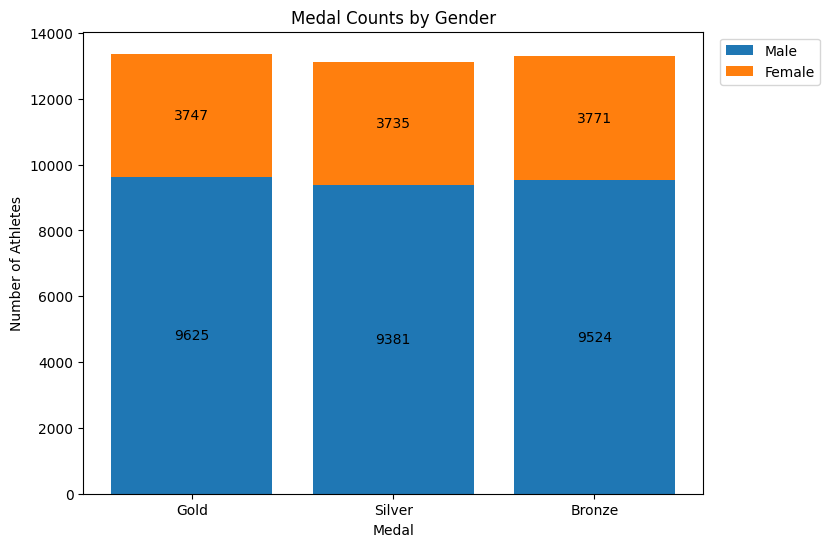

In [18]:
# athletes.info()
import numpy as np
podium_atheletes = athletes[athletes['Medal'].notna()]
order = podium_atheletes[["Medal", "Sex", "Name"]]
order = order.groupby(["Medal", "Sex"]).count()
#one bar chart is a medal
#the stack is the gender

bottom = np.zeros(3)
medals = ["Gold", "Silver", "Bronze"]
sex_counts={
    "Male":[],
    "Female": []
}
for medal in medals:
    sex_counts["Male"].append(order.loc[medal, "M"].values[0])
    sex_counts["Female"].append(order.loc[medal, "F"].values[0])
fig, ax = plt.subplots(figsize=(8,6))
for sex, sex_count in sex_counts.items():
    p = ax.bar(medals , sex_count,  label=sex, bottom=bottom)
    bottom += sex_count

    ax.bar_label(p, label_type='center')
ax.legend(loc = "upper right", bbox_to_anchor=(1.2, 1))
ax.set_title('Medal Counts by Gender')
ax.set_xlabel('Medal')
ax.set_ylabel('Number of Athletes')


# fig, ax = plt.subplots(figsize=(10,15))
# ax.bar(values.index, values['Name'], color=['turquoise', 'cyan'], alpha=0.5)

##QUESTION 3
Plot a scatterplot of weight (y-axis) against age(x-axis) of athletes. Add a vertical line at age 25 to split "younger" vs "older" athletes. Add a horizontal line at weight=70 to mark a reference threshold. Annotate both lines.

Text(0, 0.5, 'Weight')

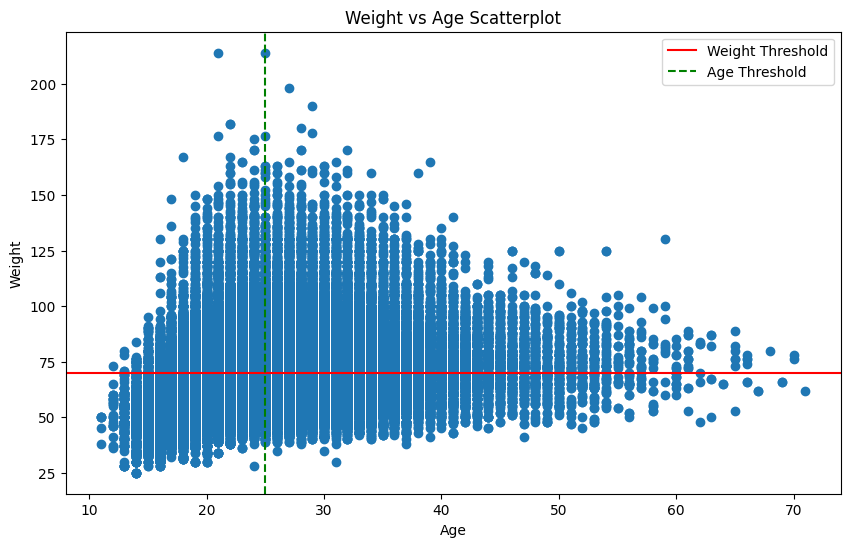

In [19]:
scatterplot_df = athletes[["Weight", "Age"]].dropna()
plt.figure(figsize=(10, 6))
plt.scatter(scatterplot_df["Age"], scatterplot_df["Weight"], alpha=1)
plt.axhline(y=70, color='r', linestyle='-', label='Weight Threshold')
plt.axvline(x=25, color='g', linestyle='--', label='Age Threshold')
plt.legend()
plt.title('Weight vs Age Scatterplot')
plt.xlabel('Age')
plt.ylabel('Weight')

##QUESTION 4
Generate a figure with four subplots arranged in a 2x2 grid. Each subplot should display a scatter plot of athlete height (y-axis) versus weight (x-axis), using data filtered for a specific sport. The sports to be shown in the subplots are: Athletics, Gymnastics, Swimming, Cycling

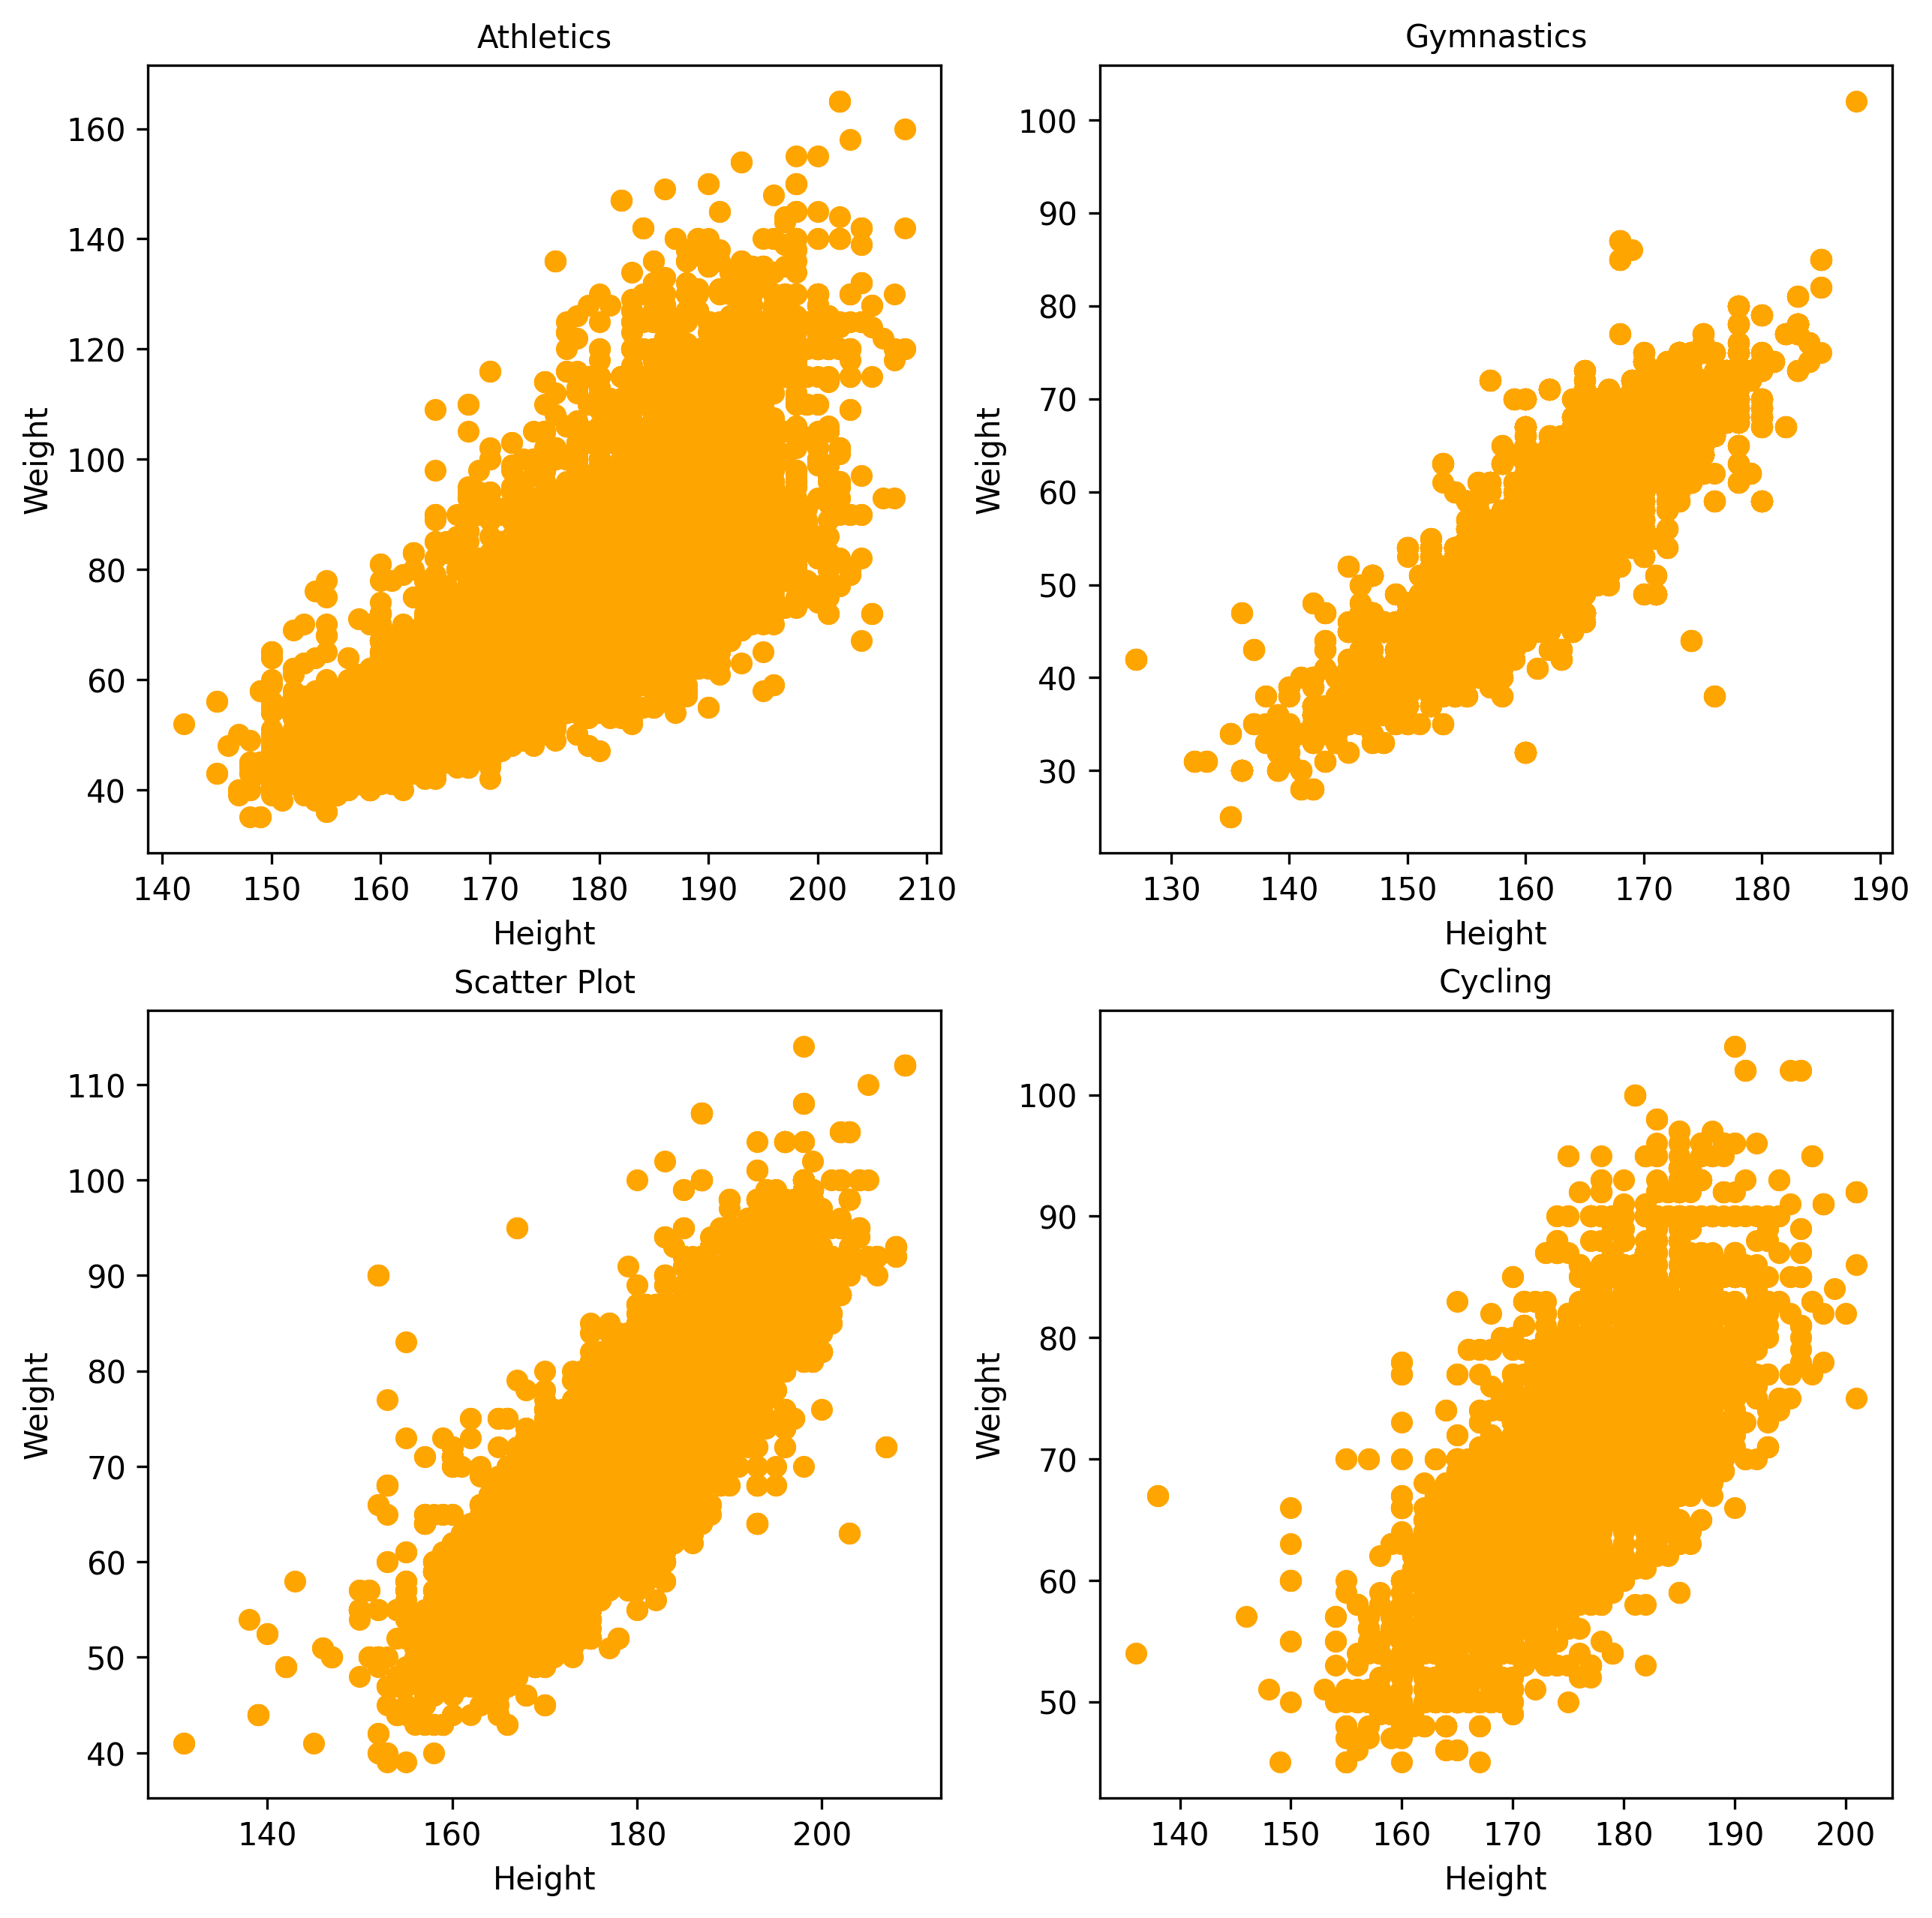

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10), dpi=300)
df = athletes[["Height", "Weight", "Sport"]]
sports = [["Athletics", "Gymnastics"], ["Swimming", "Cycling"]]

for i in range(2):
  for j in range(2):
    sport_df = df[df["Sport"] == sports[i][j]]
    scatter_x = sport_df["Height"]
    scatter_y = sport_df["Weight"]
    axs[i, j].scatter(scatter_x, scatter_y, color='orange')
    axs[1, 0].set_title("Scatter Plot", fontsize=10)
    axs[i, j].set_xlabel("Height", fontsize=10)
    axs[i, j].set_ylabel("Weight", fontsize=10)
    axs[i, j].set_title(sports[i][j], fontsize=10)


##QUESTION 5
Plot two line graphs of number of athletes per year and average height per year on the same plot. Use left y-axis for count, right y-axis for average height. Label both axes clearly.

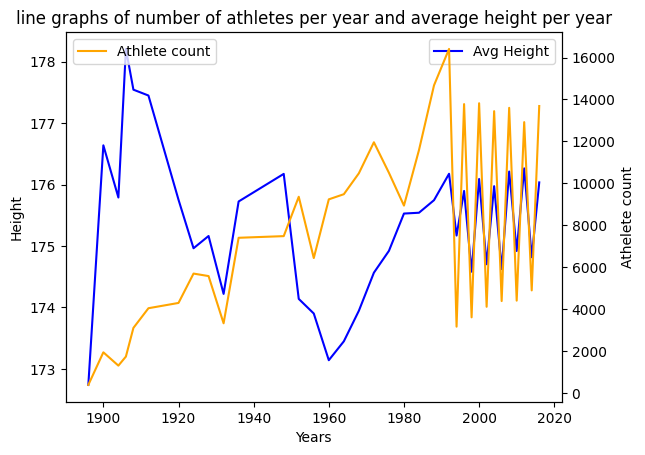

In [21]:
df = athletes[["Year", "Name"]]
df = df.groupby("Year").count()
df1 = athletes[["Year", "Height"]]
df1 = df1.groupby("Year").mean()
df1.head()
fig, ax = plt.subplots()
ax.plot(df.index, df1["Height"], label='Avg Height', color='blue')
ax.set_xlabel('Years')
ax.set_ylabel('Height')
ax.legend()
ax1 = ax.twinx()
ax1.plot(df.index, df["Name"], label='Athlete count', color='orange')
ax1.legend()
ax1.set_ylabel('Athelete count')
ax.set_title('line graphs of number of athletes per year and average height per year')
plt.show()

#SECTION 2

##QUESTION 1
Show height distribution by gender using a boxplot. Use hue to split by gender.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


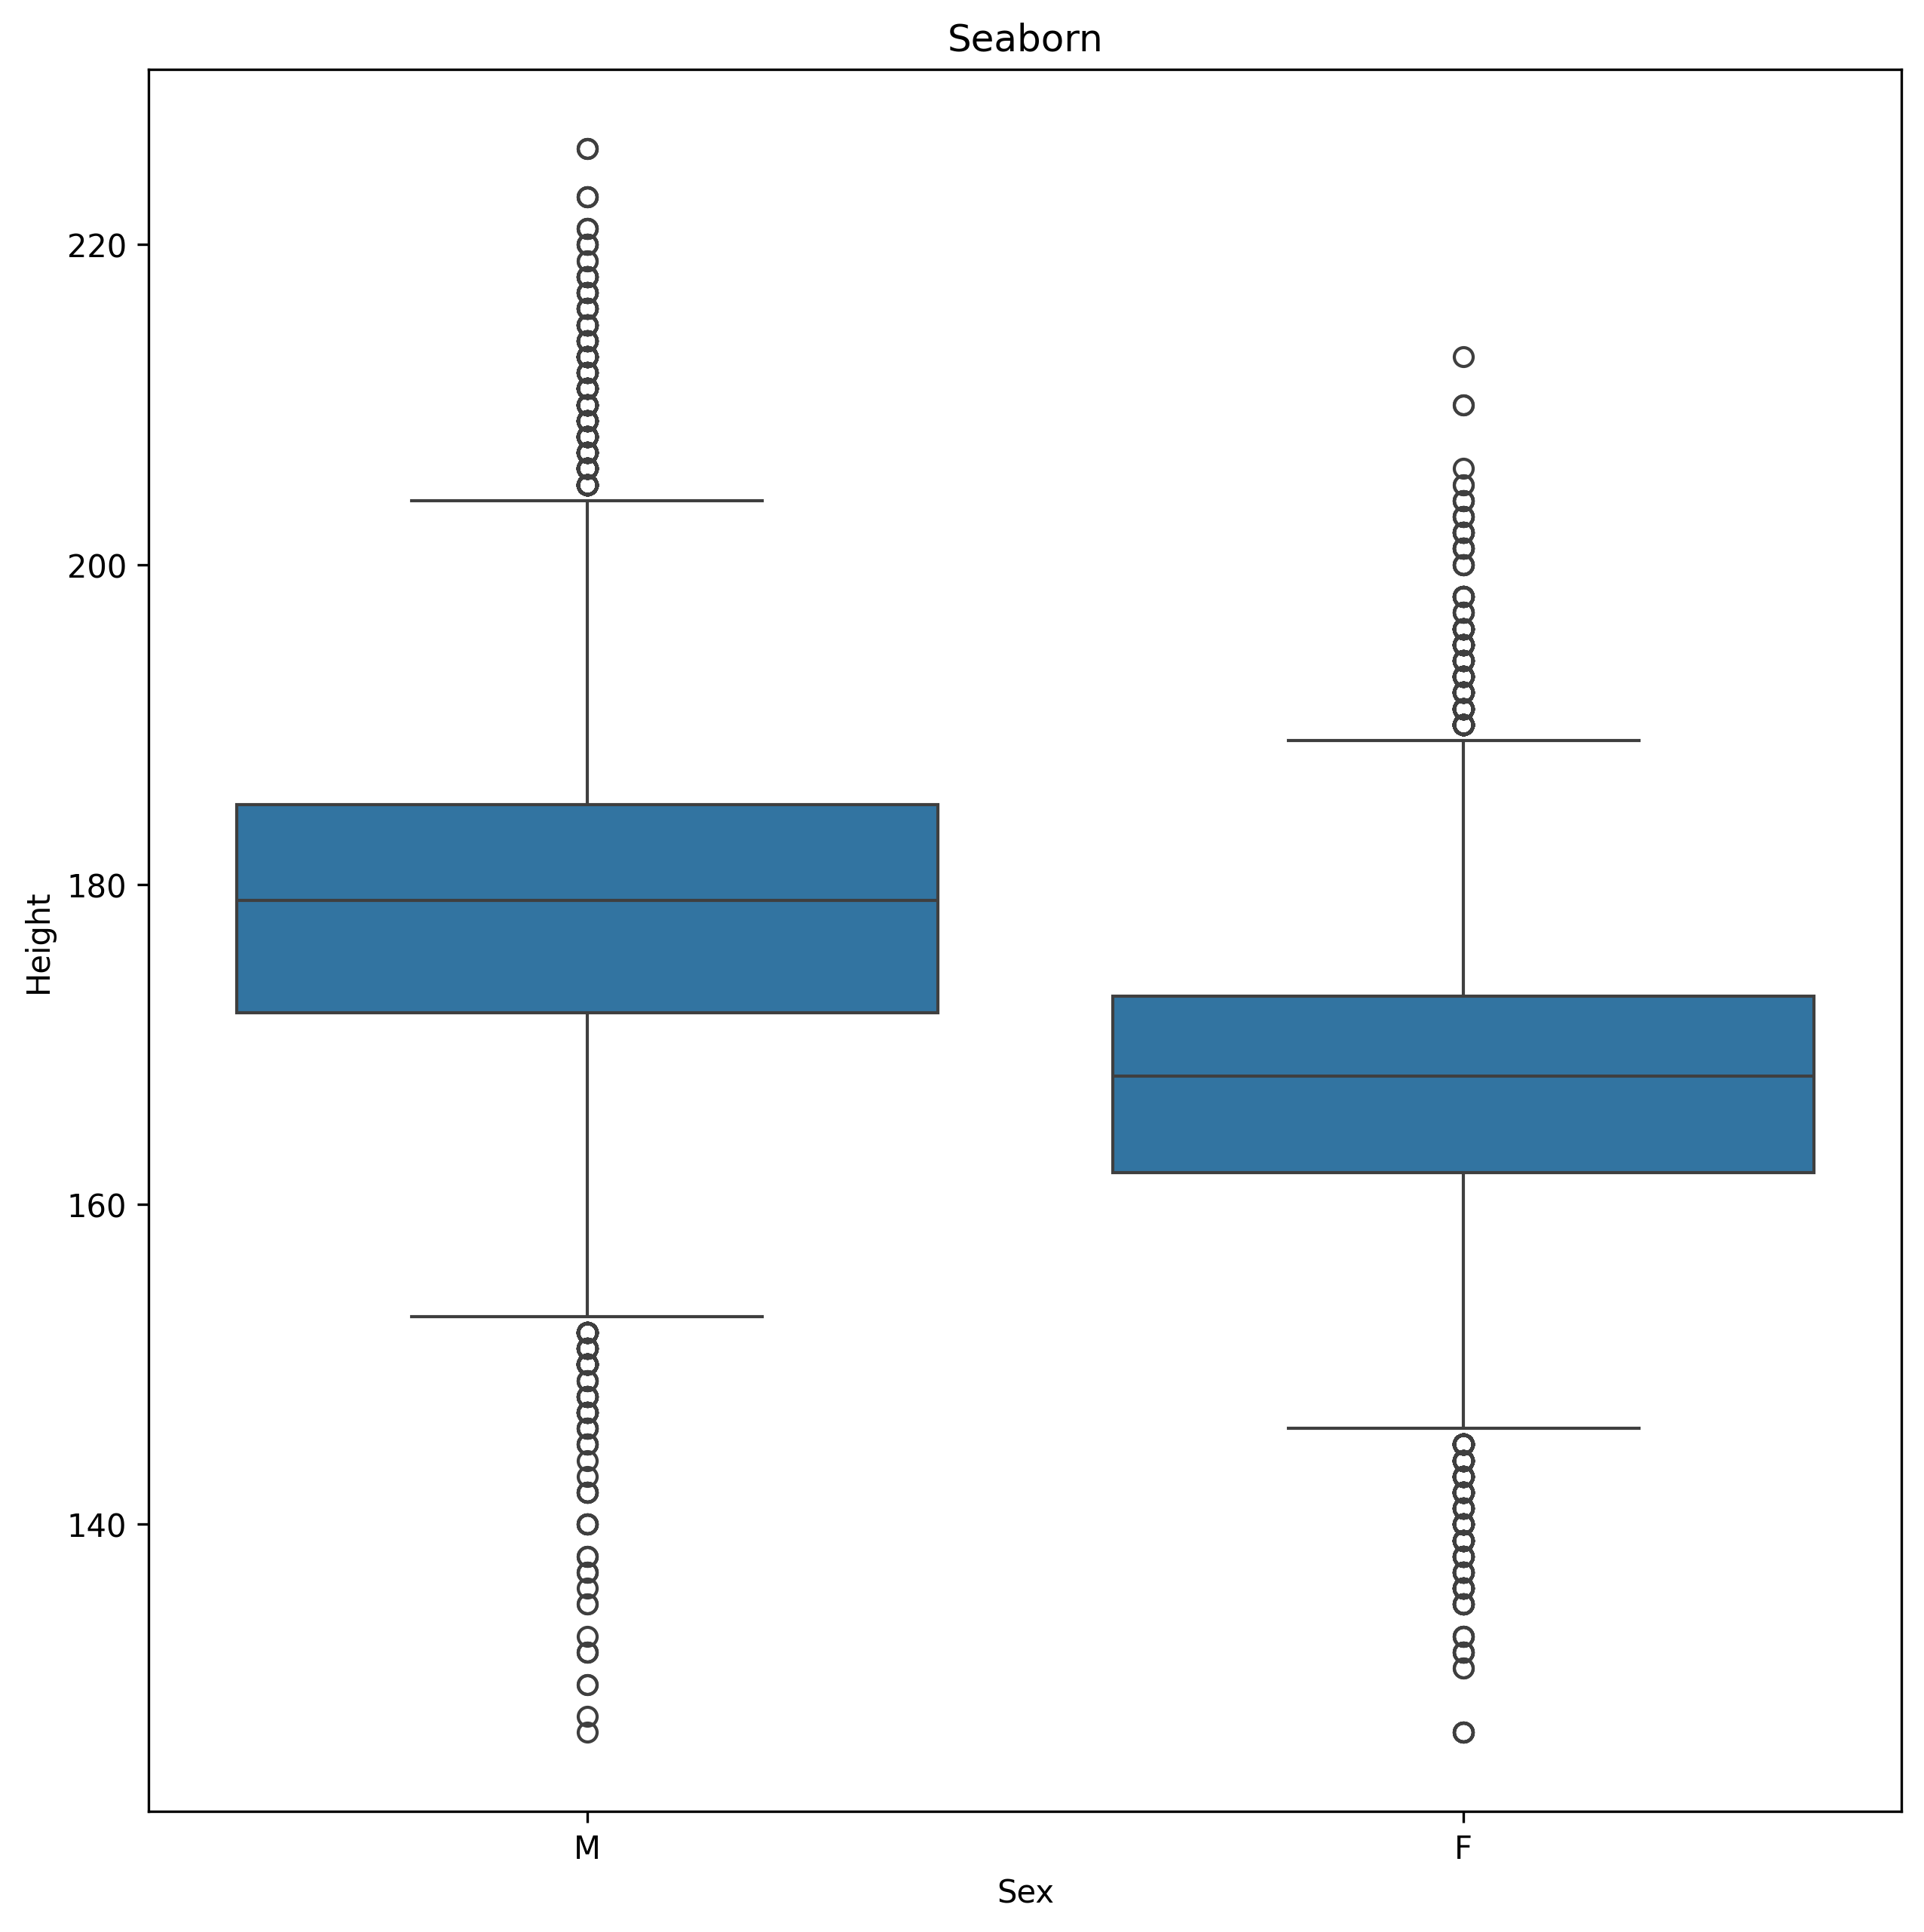

In [22]:
import seaborn as sns

athletes.info()
fig, axs = plt.subplots(figsize=(10, 10), dpi=300)
df = athletes.dropna(subset=['Height'])
sns.boxplot(data=df, x='Sex', y='Height')
plt.title("Seaborn", fontsize=12)
plt.show()

##QUESTION 2
Plot a histogram of athlete ages. Use bins=15.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


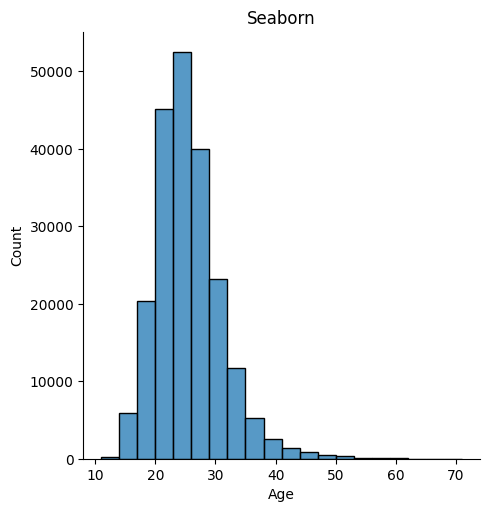

In [23]:
athletes.info()
df = athletes.dropna(subset=['Height'])
sns.displot(df, x="Age", bins=20)
plt.title("Seaborn", fontsize=12)
plt.show()

#SECTION 3
##Question 3
Plot average height per year for 3 sports (e.g., Basketball, Volleyball, Athletics). Add interactive legend so user can select/deselect each sport.

In [24]:
sports = ["Basketball", "Volleyball", "Athletics"]
df = athletes[["Year", "Sport", "Height"]]
df = df.dropna(subset=['Height'])
df1 = df[df["Sport"] == "Basketball"]

df1 = df1.groupby("Year").Height.mean()
df1.head()
df2 = df[df["Sport"] == "Volleyball"]
df2 = df2.groupby("Year").Height.mean()
df3 = df[df["Sport"] == "Athletics"]
df3 = df3.groupby("Year").Height.mean()
df1.head(50)
import plotly.graph_objects as go
fig = go.Figure()

fig.add_trace(go.Scatter(x=df1.index, y=df1, mode='lines+markers', name='Basketball'))
fig.add_trace(go.Scatter(x=df2.index, y=df2, mode='lines+markers', name='Volleyball'))
fig.add_trace(go.Scatter(x=df3.index, y=df3, mode='lines+markers', name='Athletics'))
fig.update_layout(xaxis_title="Year", yaxis_title="Average height")
fig.show()

print(df1.head())

Year
1936    182.574074
1948    185.550725
1952    187.600000
1956    186.952941
1960    188.317708
Name: Height, dtype: float64


#SECTION 4
##Q1:
Plot the locations of Kenya, Uganda, Burundi, and Rwanda on a map. Place a red marker on Kenya's location. The other countries should have grey markers.

In [37]:
import pandas as pd
import folium

# Load coordinates dataset
countries .dropna(inplace=True)
countries .head()
# Create base map centered around the equator
m = folium.Map(location=[np.mean(countries.latitude), np.mean(countries.longitude)], zoom_start=2)

# Add markers for each country
for _, row in countries.iterrows():
    if row['name'] in ['Kenya', 'Uganda', 'Burundi', 'Rwanda']:
        folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=row['name'],
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(m)
    else:
      folium.Marker(
          location=[row['latitude'], row['longitude']],
          popup=row['name'],
          icon=folium.Icon(color='gray', icon='info-sign')
      ).add_to(m)
# Display the map
m